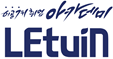

---



"해당 콘텐츠는 렛유인 반도체 데이터분석 과정 수강자를 대상으로 하는 자료로서, 복제 및 상업적 용도 사용을 엄격히 금지합니다."

## 코드실행전 유의사항
* 안녕하세요. 반도체 데이터 분석강의 수강생 여러분
* 각 엑셀 예제별 정답 코드입니다.
* 전처리 과정 및 시각화의 코드가 꼭 아래와 똑같은 방식으로 해결해야하는 것은 아니니 참고만 해주세요.
* '구글드라이브 권한할당'목차까지 코드 실행 후 'file 경로 수정' 목차 부분에서 파일 경로 수정해야합니다. 

# 필요한 패키지 import

In [ ]:
import pandas               as pd
import matplotlib.pylab     as plt # 그래프를 그리기 위한 패키지
import seaborn              as sns # 그래프를 그리기 위한 패키지

# 구글드라이브 권한 할당
아래 코드 실행 후 URL 접속 > 코드 복사 및 붙여넣기

In [ ]:
# 드라이브에 접근할 수 있도록 아래 코드 입력
from google.colab import drive

drive.mount('/content/drive')

# file 경로 수정
* **file_path_name 변수값을 본인계정의 엑셀파일경로로 수정**

In [ ]:
file_path_name = '/content/drive/MyDrive/Python/data/렛유인반도체강의/Raw data_ref_C_EX2.xlsx'

# 데이터 전처리

## 엑셀 데이터 읽기
* 경로는 개인계정의 엑셀파일 경로로 수정해야합니다.
* 경로확인방법 : 오른쪽 폴더 아이콘 > drive > content .... 

In [ ]:
# read_excel('주소및파일명', sheet_name='시트명')
df2_all = pd.read_excel(file_path_name
        , sheet_name=None) 

### df2y : Yield 시트

In [ ]:
df2y = df2_all['Yield']
df2y

In [ ]:
df2y = df2y.drop(index=[0], axis=0) 
df2y

In [ ]:
df2y.info()

In [ ]:
df2y = df2y.astype({'No.':'object', 'WFID':'object'})
for col in df2y.columns[3:]:           # for 문에서 마지막 번호는 +1로 적용해야함
    df2y[col] = pd.to_numeric(df2y[col])   #to_numeric은 pandas 함수
df2y.info()

In [ ]:
df2y.columns[0:2].astype('object')

### df2d : ET(DC) 시트

In [ ]:
df2d = df2_all['ET(DC)']
df2d

In [ ]:
df2d.info()

In [ ]:
df2d = df2d.drop(index=[0], axis=0) 
df2d

In [ ]:
df2d.info()

In [ ]:
df2d=df2d.astype({'No.':'object', 'WFID':'object'})
for col in df2d.columns[3:]:
    df2d[col] = pd.to_numeric(df2d[col])
df2d.info()

## 엑셀 데이터 읽기: 해더변경

In [ ]:
# read_excel('주소및파일명', sheet_name='시트명')
df2_all_2 = pd.read_excel(file_path_name
        , sheet_name=None
        , header = 1)  

### df2a : ADI_ACI CD 시트

In [ ]:
df2a = df2_all_2['ADI_ACI CD'] 
df2a

In [ ]:
df2a.rename(columns = {df2a.columns[0]:'No.',
                       df2a.columns[1]:'LOTID',
                       df2a.columns[2]:'WFID'}, inplace=True)

In [ ]:
df2a.info()

In [ ]:
df2a=df2a.astype({'No.':'object', 'WFID':'object'})
df2a.info()

### df2t : Thickness 시트

In [ ]:
df2t = df2_all_2['Thickness']
df2t

In [ ]:
df2t.rename(columns = {df2t.columns[0]:'No.',
                       df2t.columns[1]:'LOTID',
                       df2t.columns[2]:'WFID'}, inplace=True)

In [ ]:
df2t.info()

### df2f : FDC 시트

In [ ]:
df2f = df2_all_2['FDC']

In [ ]:
df2f.rename(columns = {df2f.columns[0]:'No.',
                       df2f.columns[1]:'LOTID',
                       df2f.columns[2]:'WFID'}, inplace=True)

In [ ]:
df2f.info()

In [ ]:
df2f=df2f.astype({'No.':'object', 'WFID':'object'})
df2f.info()

In [ ]:
colnames = df2f.columns[df2f.columns.str.contains(pat = 'EQP|CHAID|LOC')==True]
colnames

In [ ]:
for col in colnames:
    df2f[col] = df2f[col].astype('object')
df2f.info()

In [ ]:
colnames_1 = df2f.columns[df2f.columns.str.contains(pat = 'EQP|CHAID|LOC')==False]
colnames_1

In [ ]:
for col in colnames_1[3:]:
    # df1f[col] = df1f[col].astype('float')
    df2f[col] = pd.to_numeric(df2f[col])
df2f.info()

# No. 이름변경 

No. -> No 를 변경하려면 주석해제 후 실행 

In [ ]:
df2y = df2y.rename(columns={df2y.columns[0]:'No'})
df2d = df2d.rename(columns={df2d.columns[0]:'No'}) 
df2a = df2a.rename(columns={df2a.columns[0]:'No'}) 
df2t = df2t.rename(columns={df2t.columns[0]:'No'}) 
df2f = df2f.rename(columns={df2f.columns[0]:'No'}) 

# 분석
* 수율 이상치 탐지 -> 해당 수율의 번호 분석

In [ ]:
plt.figure(figsize=(10,2)) #틀생성
plt.plot(df2y['No'], df2y.BIN1, color = 'm') # b,k,w,r,m,y,g 
plt.title('Prime Trend', fontsize = 15 )
plt.xlabel('No', fontsize = 10)
plt.ylabel('Prime', fontsize = 10)
plt.show() 

In [ ]:
df2y_1 = df2y['BIN1'].loc[df2y['BIN1'] < 70] 
df2y_1
# df2y_1.count() # 63

In [ ]:
for i in df2y[3:]:
  plt.figure(figsize=(10,2)) #틀생성
  plt.plot(df2y['No'], df2y[i], color = 'm') # b,k,w,r,m,y,g 
  plt.title(i, fontsize = 15 )
  plt.xlabel('No', fontsize = 10)
  plt.ylabel(i, fontsize = 10)
  plt.show() 

In [ ]:
for i in df2a:
  plt.figure(figsize=(10,2)) #틀생성
  plt.plot(df2a['No'], df2a[i], color = 'm') # b,k,w,r,m,y,g 
  plt.title(i, fontsize = 15 )
  plt.xlabel('No', fontsize = 10)
  plt.ylabel(i, fontsize = 10)
  plt.show() 

In [ ]:
for i in df2d:
  plt.figure(figsize=(10,2)) #틀생성
  plt.plot(df2d['No'], df2d[i], color = 'm') # b,k,w,r,m,y,g 
  plt.title(i, fontsize = 15 )
  plt.xlabel('No', fontsize = 10)
  plt.ylabel(i, fontsize = 10)
  plt.show() 

In [ ]:
for i in df2t:
  plt.figure(figsize=(10,2)) #틀생성
  plt.plot(df2t['No'], df2t[i], color = 'm') # b,k,w,r,m,y,g 
  plt.title(i, fontsize = 15 )
  plt.xlabel('No', fontsize = 10)
  plt.ylabel(i, fontsize = 10)
  plt.show() 

In [ ]:
for i in df2f:
  plt.figure(figsize=(10,2)) #틀생성
  plt.plot(df2f['No'], df2f[i], color = 'm') # b,k,w,r,m,y,g 
  plt.title(i, fontsize = 15 )
  plt.xlabel('No', fontsize = 10)
  plt.ylabel(i, fontsize = 10)
  plt.show() 

1. 게이트 산화막 두께가 얇아지면 커패시턴스 값이 커지게 되고, 그에 따라 보다 낮은 전압을 통해 많은 전하를 유도할 수 있기 때문에 산화막 두께가 얇아질수록 문턱전압은 낮아진다.

2. 채널의 저항은 아래 공식에 의해 도체의 길이에 비례하고, 면적에 반비례하는 관계가 있습니다. 따라서 채널이 짧아질수록 저항은 감소하여 낮은 전압에서도 보다 

-채널이 짧아지고 드레인 공핍 영역이 증가하면서 

게이트전압이 아닌 드레인 전압에 의해 채널 - 소스간의 내부 전위 장벽이 낮아짐.

이로 인해 문턱전압 이하에서 누설 드레인 전류가 흐르는 현상

-드레인 전압이 증가할 수록 DIBL은 더 심해짐.

*원래는 게이트 전압이 0V일 때 소스에서 드레인으로의 전자 흐름을 막는 내부 전위 장벽이 존재하고 이것을 낮출 수 있는 유일한 전압은 게이트 전압이어야함. 

[Solution]

-채널길이가 짧아지는 만큼 소스-드레인 깊이를 얇게하고 사용 전압을 줄여 공핍 영역 폭을 줄여주면 됨.

In [ ]:
# 예제) 이상치 탐지
# 박스플롯의 이상치 탐지 방식으로 BIN1의 이상치를 찾고 그에 해당하는 행을 추출하기
# 사분위수 계산
q1 = df2y['BIN1'].quantile(0.25) #1 사분위수(Q1) (25% 지점수)
q3 = df2y['BIN1'].quantile(0.75) #3 사분위수(Q3) (75% 지점수)
print('Q1:', q1) 
print('Q3:', q3) 

# IQR 계산
IQR = q3 - q1
print('IQR:', IQR) 

# 최소값 최대값 계산
min_new = q1 - 1.5 * IQR
max_new = q3 + 1.5 * IQR
print('IQR min:', min_new)
print('IQR max:', max_new) 
# min_new = 75
# max_new = 95

print('실제 min:', df2y['BIN1'].min()) 
print('실제 max:', df2y['BIN1'].max()) 

search_df = df2y[(df2y['BIN1'] < min_new) | (df2y['BIN1'] > max_new)]  # 이상치 추출
search_df_o = df2y[(df2y['BIN1'] >= min_new) & (df2y['BIN1'] <= max_new)] # 정상치 추출
# | :shift + \
print(search_df.shape) #행,열
print(search_df)
print(search_df_o)

In [ ]:
for col in df2y:
  merge_org = df2y.sort_values(by=[col]) # 전체데이터
  merge_IQR = search_df.sort_values(by=[col]) # 이상치데이터

  plt.subplot(121) # 전체데이터

  a = merge_org.groupby(col)[col].count() 
  b= merge_org[col].unique()
  plt.pie(a, labels=b, autopct='%.1f%%')
  plt.title(f'{col}_orgin')
  

  plt.subplot(122) # 전체데이터

  a = merge_IQR.groupby(col)[col].count() 
  b= merge_IQR[col].unique()
  plt.pie(a, labels=b, autopct='%.1f%%')
  plt.title(f'{col}_IQR')
  plt.show()